In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import urllib.request
import os
from scipy import ndimage
import random


# Домашнее задание по лекции: Локальные дескрипторы и сверточные нейронные сети

## Часть 1. Локальные дескрипторы (SIFT) и backpropagation

В этой части мы будем работать с алгоритмом SIFT и проанализируем его основные этапы.

In [ ]:
# Загрузка двух тестовых изображений из ImageNet
print("Загрузка изображений для Части 1...")

if not os.path.exists('images'):
    os.makedirs('images')

# Загружаем изображения из открытых источников ImageNet
urls = [
    'https://github.com/EliSchwartz/imagenet-sample-images/raw/master/n01440764_tench.JPEG',
    'https://github.com/EliSchwartz/imagenet-sample-images/raw/master/n02123045_tabby.JPEG'
]

for i, url in enumerate(urls):
    urllib.request.urlretrieve(url, f'images/image{i+1}.jpg')

img1 = cv2.imread('images/image1.jpg')
img2 = cv2.imread('images/image2.jpg')

img1 = cv2.resize(img1, (400, 300))
img2 = cv2.resize(img2, (400, 300))

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

print("Изображения успешно загружены и обработаны!")

Загрузка изображений для Части 1...
Изображения успешно загружены и обработаны!


Исходные изображения:


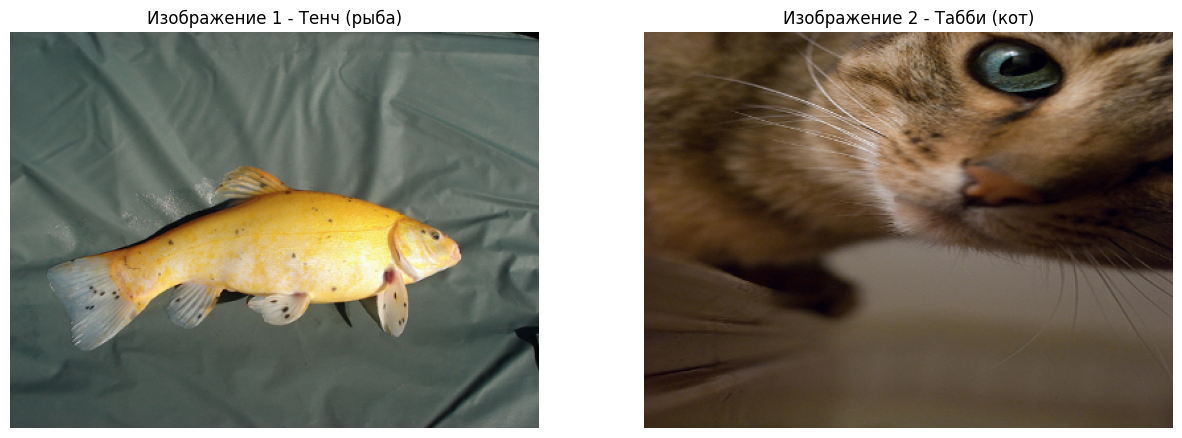

Размер изображения 1: (300, 400)
Размер изображения 2: (300, 400)


In [ ]:
# Отображаем исходные изображения
print("Исходные изображения:")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(img1_rgb)
axes[0].set_title('Изображение 1 - Тенч (рыба)')
axes[0].axis('off')

axes[1].imshow(img2_rgb)
axes[1].set_title('Изображение 2 - Табби (кот)')
axes[1].axis('off')
plt.show()

print(f"Размер изображения 1: {gray1.shape}")
print(f"Размер изображения 2: {gray2.shape}")

### Извлечение ключевых точек и SIFT-дескрипторов

Теперь извлечем ключевые точки и дескрипторы SIFT для обоих изображений.

In [ ]:
# Инициализация SIFT детектора и извлечение ключевых точек
print("Извлечение ключевых точек SIFT...")

sift = cv2.SIFT_create()

keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

print(f"Найдено ключевых точек на изображении 1: {len(keypoints1)}")
print(f"Найдено ключевых точек на изображении 2: {len(keypoints2)}")
print(f"Размерность дескрипторов: {descriptors1.shape[1]} элементов на точку")

Извлечение ключевых точек SIFT...
Найдено ключевых точек на изображении 1: 155
Найдено ключевых точек на изображении 2: 206
Размерность дескрипторов: 128 элементов на точку


Визуализация ключевых точек...


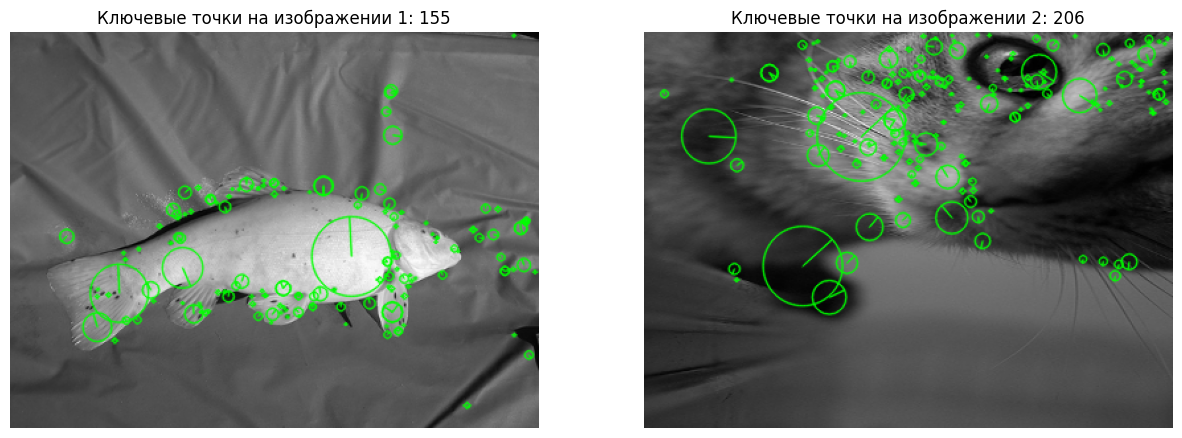

In [ ]:
# Визуализация ключевых точек на изображениях
print("Визуализация ключевых точек...")

img1_with_keypoints = cv2.drawKeypoints(gray1, keypoints1, None, color=(0, 255, 0),
                                       flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_with_keypoints = cv2.drawKeypoints(gray2, keypoints2, None, color=(0, 255, 0),
                                       flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(img1_with_keypoints)
axes[0].set_title(f'Ключевые точки на изображении 1: {len(keypoints1)}')
axes[0].axis('off')

axes[1].imshow(img2_with_keypoints)
axes[1].set_title(f'Ключевые точки на изображении 2: {len(keypoints2)}')
axes[1].axis('off')
plt.show()

In [ ]:
# Покажем несколько дескрипторов
print("Анализ дескрипторов SIFT:")
print(f"Размерность дескрипторов: {descriptors1.shape}")
print("\nПервые 3 дескриптора (первые 10 элементов каждого):")
for i in range(3):
    print(f"Дескриптор {i+1}: {descriptors1[i][:10]}...")

print(f"\nСтатистика дескрипторов:")
print(f"Минимальное значение: {np.min(descriptors1):.2f}")
print(f"Максимальное значение: {np.max(descriptors1):.2f}")
print(f"Среднее значение: {np.mean(descriptors1):.2f}")

Анализ дескрипторов SIFT:
Размерность дескрипторов: (155, 128)

Первые 3 дескриптора (первые 10 элементов каждого):
Дескриптор 1: [  7.  25.   6.   4.  40.  30.   6.   4.  12. 126.]...
Дескриптор 2: [33. 19.  8. 27. 18.  0.  0.  1. 20. 47.]...
Дескриптор 3: [ 7.  0.  0.  0. 21.  5.  0.  2. 33.  0.]...

Статистика дескрипторов:
Минимальное значение: 0.00
Максимальное значение: 191.00
Среднее значение: 24.32


### Сопоставление дескрипторов между изображениями

Теперь выполним сопоставление дескрипторов между двумя изображениями с помощью BFMatcher.

In [ ]:
# Сопоставление дескрипторов
print("Сопоставление дескрипторов между изображениями...")

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

matches = bf.match(descriptors1, descriptors2)

matches = sorted(matches, key=lambda x: x.distance)

print(f"Найдено совпадений: {len(matches)}")
print(f"Лучшее расстояние: {matches[0].distance:.2f}")
print(f"Худшее расстояние: {matches[-1].distance:.2f}")

Сопоставление дескрипторов между изображениями...
Найдено совпадений: 58
Лучшее расстояние: 148.28
Худшее расстояние: 409.67


Визуализация сопоставлений...


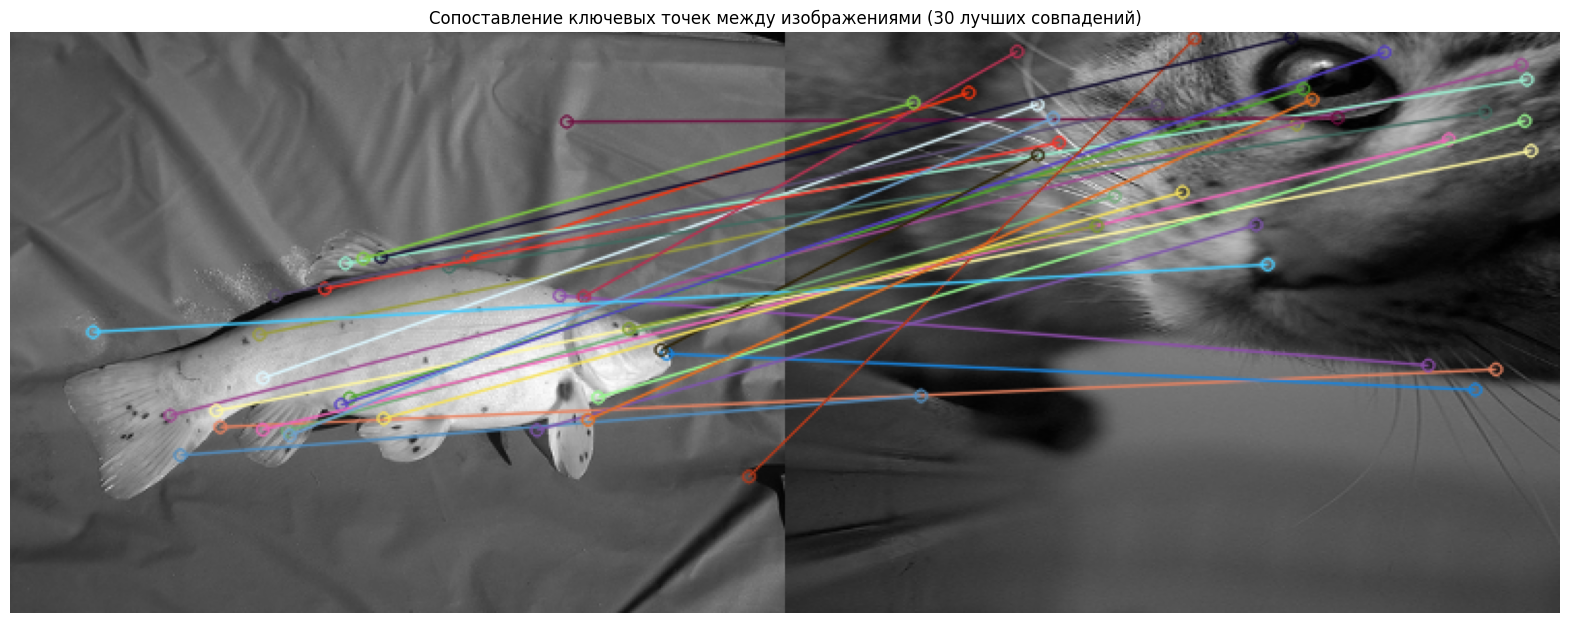

In [ ]:
# Визуализируем первые 30 лучших совпадений
print("Визуализация сопоставлений...")

img_matches = cv2.drawMatches(gray1, keypoints1, gray2, keypoints2,
                             matches[:30], None,
                             flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(20, 10))
plt.imshow(img_matches)
plt.title(f'Сопоставление ключевых точек между изображениями (30 лучших совпадений)')
plt.axis('off')
plt.show()

## Анализ алгоритма SIFT и backpropagation

### Основные этапы алгоритма SIFT:

1. **Масштабно-пространственная фильтрация (Difference-of-Gaussians)**
   - Создание пирамиды гауссианов с разными σ (сигма)
   - Вычисление разности соседних гауссианов (DoG)
   - Поиск экстремумов в пространстве-масштабе

2. **Выбор экстремумов (ключевых точек)**
   - Поиск локальных максимумов/минимумов в DoG
   - Отсечение слабых точек по порогу контраста
   - Удаление точек на краях с помощью анализа гессиана

3. **Назначение ориентаций**
   - Вычисление градиентов в окрестности ключевой точки
   - Построение гистограммы ориентаций (36 бинов по 10 градусов)
   - Назначение доминирующей ориентации

4. **Построение дескрипторов**
   - Разделение области на 4x4 подрегиона
   - Построение гистограмм градиентов (8 ориентаций) для каждого подрегиона
   - Нормализация дескриптора для инвариантности к освещению

### Backpropagation через этапы SIFT:

Для каждого этапа можно вычислить производные:

- **Gaussian Blur**: производная = свертка с транспонированным гауссовым ядром
- **Difference-of-Gaussians**: производная = разность производных двух гауссовых фильтров  
- **Градиенты**: производные по направлениям x и y могут быть вычислены через операторы Собеля
- **Гистограммы**: производная через билинейную интерполяцию при распределении весов
- **Нормализация**: производная включает правило частного для L2-нормировки

Однако SIFT не является дифференцируемой функцией в традиционном смысле из-за операций поиска экстремумов и дискретизации, что затрудняет прямое применение backpropagation.

Демонстрация Gaussian Blur и Difference of Gaussians...


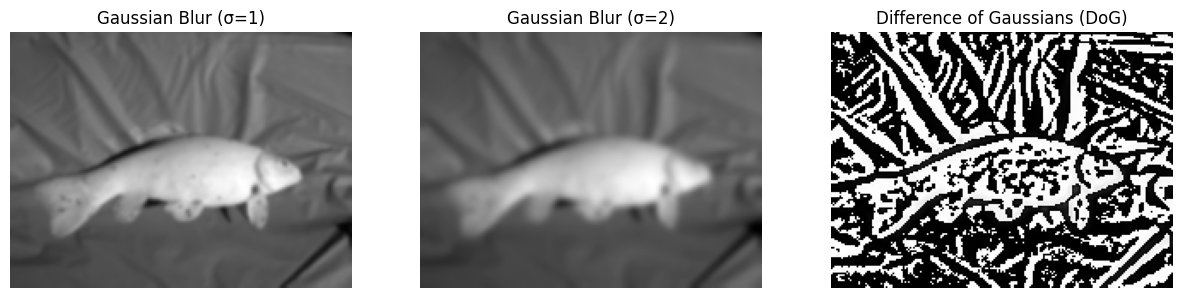

In [ ]:
# Демонстрация Gaussian Blur и Difference of Gaussians
print("Демонстрация Gaussian Blur и Difference of Gaussians...")

gray1_small = cv2.resize(gray1, (200, 150))

blur1 = cv2.GaussianBlur(gray1_small, (0, 0), sigmaX=1)
blur2 = cv2.GaussianBlur(gray1_small, (0, 0), sigmaX=2)
dog = blur2 - blur1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(blur1, cmap='gray')
axes[0].set_title('Gaussian Blur (σ=1)')
axes[0].axis('off')

axes[1].imshow(blur2, cmap='gray')
axes[1].set_title('Gaussian Blur (σ=2)')
axes[1].axis('off')

axes[2].imshow(dog, cmap='gray')
axes[2].set_title('Difference of Gaussians (DoG)')
axes[2].axis('off')
plt.show()

## Алгоритм SIFT: Пошаговое описание

### 1. Создание масштабного пространства

**Цель:** Найти устойчивые ключевые точки на разных масштабах

- Берем исходное изображение
- Создаем несколько октав (уровней уменьшения изображения)
- Для каждой октавы создаем несколько масштабов с разной степенью размытия
- Размытие делаем гауссовым фильтром с увеличивающимся σ

**Математическая основа:**
- L(x,y,σ) = G(x,y,σ) * I(x,y)
где:
G(x,y,σ) = (1/2πσ²) * exp(-(x²+y²)/2σ²) - Гауссово ядро
I(x,y) - исходное изображение


### 2. Разность гауссианов (DoG)

**Цель:** Выявить устойчивые к масштабу ключевые точки

- Для каждой октавы вычитаем соседние масштабы
- Получаем DoG-пирамиду - разности размытых изображений

**Формула:**
- D(x,y,σ) = L(x,y,kσ) - L(x,y,σ)


### 3. Поиск ключевых точек

**Цель:** Найти локальные экстремумы в масштабном пространстве

- Ищем локальные экстремумы в DoG-пирамиде
- Сравниваем каждую точку с 8 соседями в том же масштабе
- И с 9+9=18 соседями в соседних масштабах
- Всего 26 сравнений для каждой точки

### 4. Фильтрация точек

**Цель:** Отобрать только качественные ключевые точки

- Убираем точки с низкой контрастностью (порог по значению DoG)
- Убираем точки на краях (анализ матрицы Гессе)

**Критерии отбора:**
- Контраст: |D(x)| > 0.03 (обычно)
- Краевой отклик: ratio главных собственных значений < 10

### 5. Назначение ориентации

**Цель:** Сделать дескрипторы инвариантными к вращению

- Для каждой оставшейся точки вычисляем градиенты в окрестности
- Строим гистограмму из 36 корзин (по 10 градусов)
- Назначаем основную ориентацию по максимуму гистограммы

**Вычисление градиентов:**
- magnitude = √(Iₓ² + Iᵧ²)
- orientation = atan2(Iᵧ, Iₓ)
где:
Iₓ = I(x+1,y) - I(x-1,y) - производная по x
Iᵧ = I(x,y+1) - I(x,y-1) - производная по y


### 6. Создание дескрипторов

**Цель:** Создать уникальные и устойчивые описания ключевых точек

- Вокруг точки берем область 16×16 пикселей
- Разбиваем на 4×4 = 16 подобластей
- Для каждой подобласти строим гистограмму из 8 ориентаций
- Получаем дескриптор 4×4×8 = 128 измерений
- Нормализуем дескриптор для устойчивости к освещению

**Особенности:**
- Трилинейная интерполяция для распределения весов
- L2-нормализация для инвариантности к контрасту
- Обрезка больших значений для устойчивости к нелинейному освещению

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import time

## Часть 2. Сверточные нейронные сети: ResNet и затухающие градиенты

В этой части мы сравним обычную CNN и ResNet, проанализируем проблему затухающих градиентов и покажем, как skip-connections в ResNet помогают решить эту проблему.

In [ ]:
# Загрузка и подготовка данных CIFAR-10 (упрощенный аналог ImageNet)
print("Загрузка и подготовка данных...")

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

class_names = ['самолет', 'автомобиль', 'птица', 'кот', 'олень',
               'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

# Выбираем классы 3 (кот) и 5 (собака) для бинарной классификации
class_1, class_2 = 3, 5

train_mask = (y_train[:, 0] == class_1) | (y_train[:, 0] == class_2)
test_mask = (y_test[:, 0] == class_1) | (y_test[:, 0] == class_2)

x_train_binary = x_train[train_mask]
y_train_binary = y_train[train_mask]
x_test_binary = x_test[test_mask]
y_test_binary = y_test[test_mask]

y_train_binary = (y_train_binary == class_1).astype(int)
y_test_binary = (y_test_binary == class_1).astype(int)

print(f"Размер обучающей выборки: {x_train_binary.shape}")
print(f"Размер тестовой выборки: {x_test_binary.shape}")
print(f"Классы: {class_names[class_1]} (1) vs {class_names[class_2]} (0)")
print(f"Распределение классов в обучающей выборке: {np.unique(y_train_binary, return_counts=True)}")

Загрузка и подготовка данных...
Размер обучающей выборки: (10000, 32, 32, 3)
Размер тестовой выборки: (2000, 32, 32, 3)
Классы: кот (1) vs собака (0)
Распределение классов в обучающей выборке: (array([0, 1]), array([5000, 5000]))


Примеры изображений из датасета:


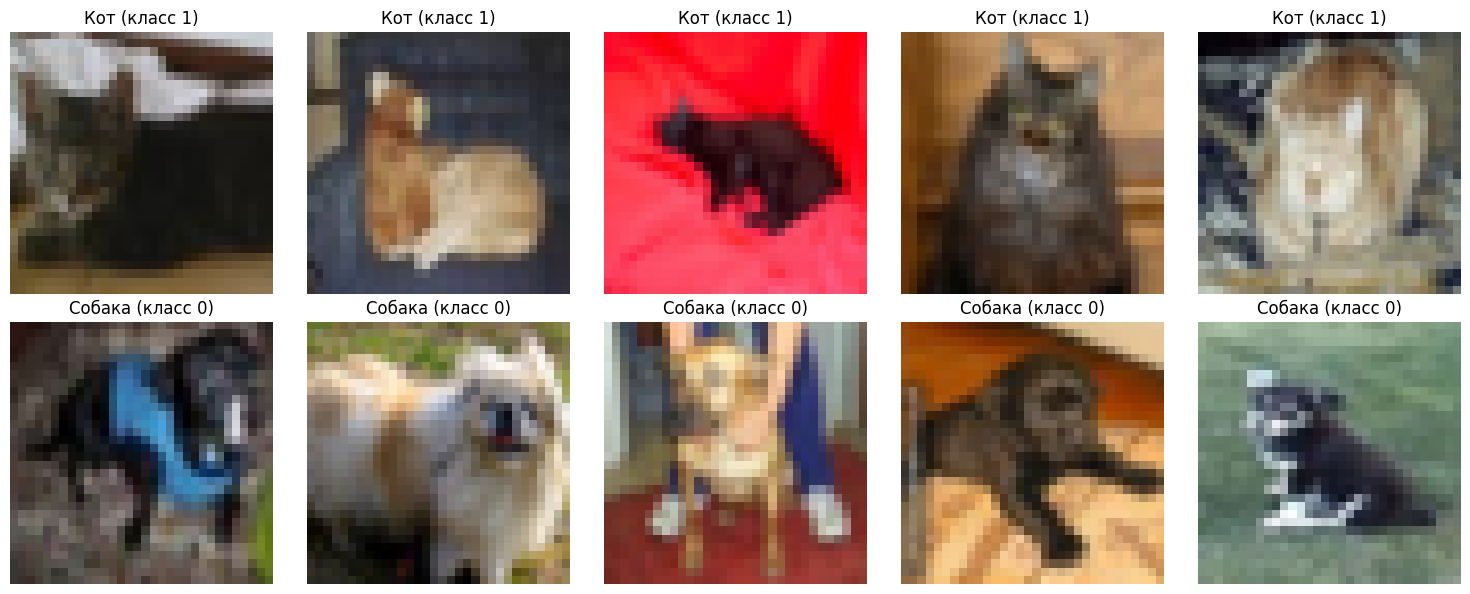

In [ ]:
# Визуализация примеров данных
print("Примеры изображений из датасета:")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    cat_idx = np.where(y_train_binary == 1)[0][i]
    axes[0, i].imshow(x_train_binary[cat_idx])
    axes[0, i].set_title(f'Кот (класс 1)')
    axes[0, i].axis('off')

    dog_idx = np.where(y_train_binary == 0)[0][i]
    axes[1, i].imshow(x_train_binary[dog_idx])
    axes[1, i].set_title(f'Собака (класс 0)')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

### Создание простой CNN модели

In [ ]:
# Создание простой CNN модели
def create_simple_cnn(input_shape=(32, 32, 3)):
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

simple_cnn = create_simple_cnn()
simple_cnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("Простая CNN модель создана:")
simple_cnn.summary()

Простая CNN модель создана:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### Создание ResNet модели

In [ ]:
# Создание упрощенной ResNet модели с skip-connections
def residual_block(x, filters, kernel_size=3, stride=1):
    # Shortcut connection
    shortcut = x

    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

def create_resnet(input_shape=(32, 32, 3)):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = residual_block(x, 32)
    x = layers.MaxPooling2D(2)(x)

    x = residual_block(x, 64)
    x = layers.MaxPooling2D(2)(x)

    x = residual_block(x, 128)
    x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model

resnet_model = create_resnet()
resnet_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

print("ResNet модель создана:")
resnet_model.summary()

ResNet модель создана:


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 32, 32,    │        896 │ input_layer_11[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_35[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_64[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_36[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_65[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation_35[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 32, 32,    │          0 │ add_15[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_33    │ (None, 16, 16,    │          0 │ activation_37[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_33… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_66[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 16, 16,    │     36,928 │ activation_38[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_68 (Conv2D)  │ (None, 16, 16,    │      2,112 │ max_pooling2d_33

 Total params: 326,017 (1.24 MB)

 Trainable params: 324,673 (1.24 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [ ]:
# Правильная реализация GradientTracker
class GradientTracker(keras.callbacks.Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.validation_data = validation_data
        self.gradient_history = {}

    def on_train_begin(self, logs=None):
        self.gradient_history = {}
        for layer in self.model.layers:
            for weight in layer.trainable_weights:
                self.gradient_history[weight.name] = []

    def on_epoch_end(self, epoch, logs=None):
        x_val, y_val = self.validation_data
        sample_size = min(100, len(x_val))
        x_sample = tf.convert_to_tensor(x_val[:sample_size])
        y_sample = tf.convert_to_tensor(y_val[:sample_size])

        with tf.GradientTape() as tape:
            predictions = self.model(x_sample, training=False)
            loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_sample, predictions))

        gradients = tape.gradient(loss, self.model.trainable_weights)

        for weight, grad in zip(self.model.trainable_weights, gradients):
            if grad is not None:
                grad_norm = tf.norm(grad).numpy()
                self.gradient_history[weight.name].append(float(grad_norm))
            else:
                print(f"Warning: Gradient for {weight.name} is None")  # Отладка

simple_cnn_tracker = GradientTracker((x_test_binary, y_test_binary))
resnet_tracker = GradientTracker((x_test_binary, y_test_binary))

In [ ]:
# Обучаем простую CNN модель
print("Обучение простой CNN модели...")
start_time = time.time()

simple_cnn_history = simple_cnn.fit(
    x_train_binary, y_train_binary,
    batch_size=32,
    epochs=15,
    validation_data=(x_test_binary, y_test_binary),
    callbacks=[simple_cnn_tracker],
    verbose=1
)

cnn_time = time.time() - start_time
print(f"Обучение CNN завершено за {cnn_time:.2f} секунд")

Обучение простой CNN модели...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.5460 - loss: 0.6831 - val_accuracy: 0.6750 - val_loss: 0.6025
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.6964 - loss: 0.5881 - val_accuracy: 0.7350 - val_loss: 0.5319
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 78ms/step - accuracy: 0.7213 - loss: 0.5363 - val_accuracy: 0.7395 - val_loss: 0.5129
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.7573 - loss: 0.4956 - val_accuracy: 0.7585 - val_loss: 0.4963
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 72ms/step - accuracy: 0.7848 - loss: 0.4486 - val_accuracy: 0.7615 - val_loss: 0.4792
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.8083 - loss: 0.4050 - val_accuracy: 0.7645 - val_loss: 0.4765
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.8387 - loss: 0.3606 - val_accuracy: 0.7785 - val_loss: 0.4900
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - acc

In [ ]:
# Обучаем ResNet модель
print("Обучение ResNet модели...")
start_time = time.time()

resnet_history = resnet_model.fit(
    x_train_binary, y_train_binary,
    batch_size=32,
    epochs=15,
    validation_data=(x_test_binary, y_test_binary),
    callbacks=[resnet_tracker],
    verbose=1
)

resnet_time = time.time() - start_time
print(f"Обучение ResNet завершено за {resnet_time:.2f} секунд")

Обучение ResNet модели...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 115s 344ms/step - accuracy: 0.5592 - loss: 0.7439 - val_accuracy: 0.5315 - val_loss: 0.6797
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 117s 371ms/step - accuracy: 0.6908 - loss: 0.5923 - val_accuracy: 0.7115 - val_loss: 0.5748
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 114s 365ms/step - accuracy: 0.7526 - loss: 0.5108 - val_accuracy: 0.5395 - val_loss: 0.9423
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 118s 377ms/step - accuracy: 0.7840 - loss: 0.4592 - val_accuracy: 0.7500 - val_loss: 0.5367
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 114s 364ms/step - accuracy: 0.8063 - loss: 0.4139 - val_accuracy: 0.6535 - val_loss: 0.5995
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 115s 367ms/step - accuracy: 0.8342 - loss: 0.3738 - val_accuracy: 0.7780 - val_loss: 0.4652
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 114s 365ms/step - accuracy: 0.8447 - loss: 0.3467 - val_accuracy: 0.7895 - val_loss: 0.4747
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 371ms

### Визуализация результатов обучения

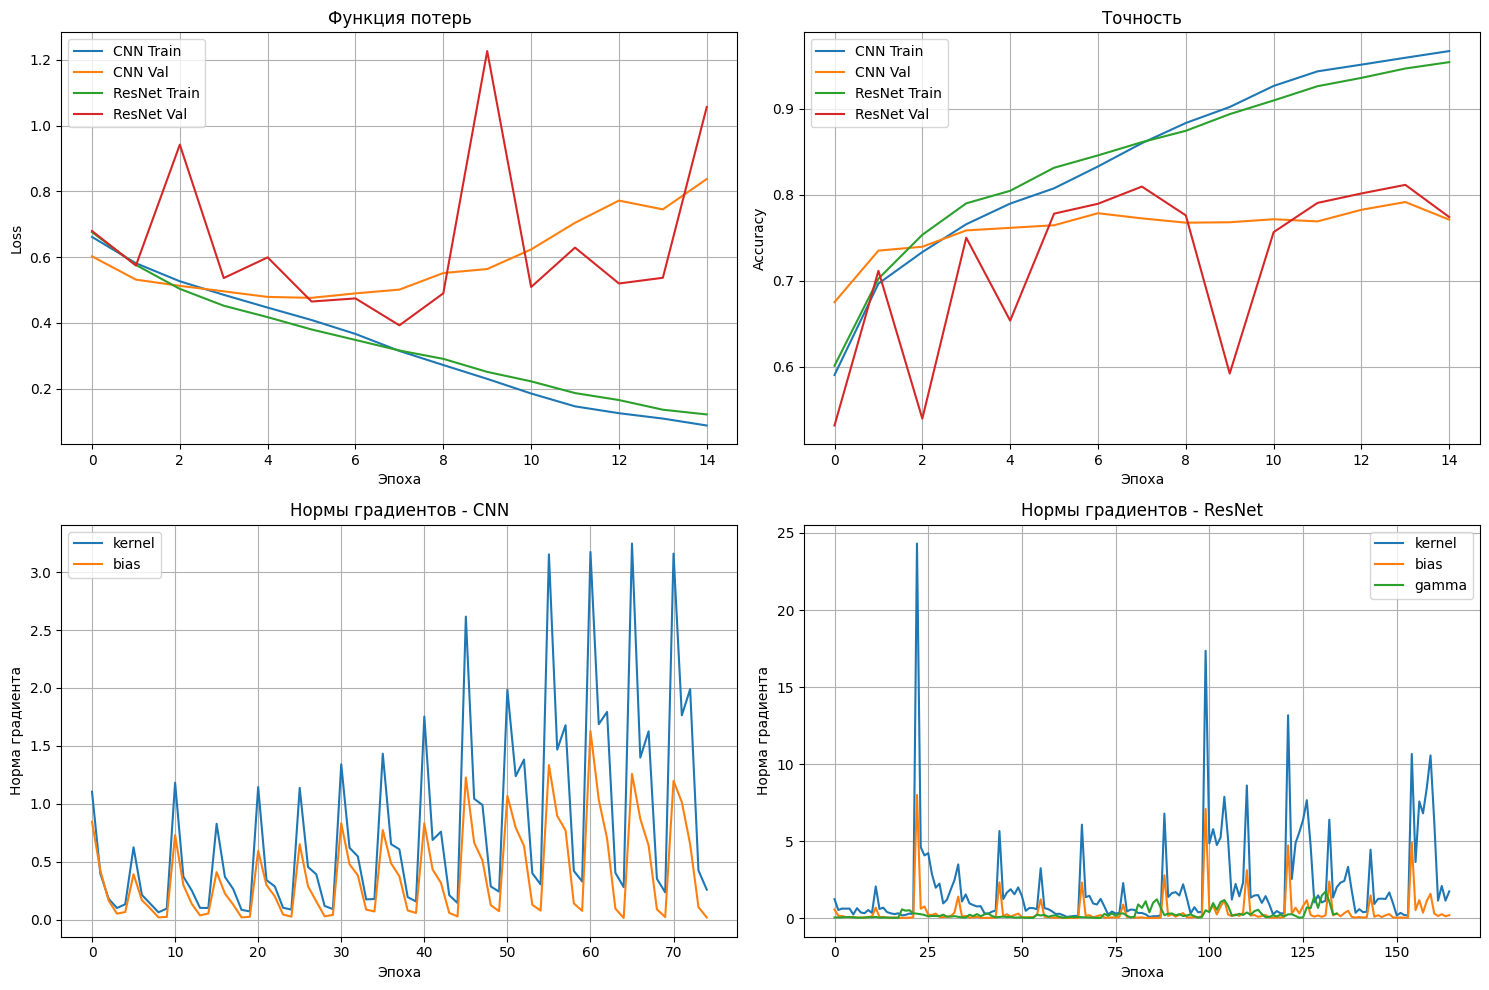

In [ ]:
# Визуализация градиентов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Графики потерь (Loss)
axes[0, 0].plot(simple_cnn_history.history['loss'], label='CNN Train')
axes[0, 0].plot(simple_cnn_history.history['val_loss'], label='CNN Val')
axes[0, 0].plot(resnet_history.history['loss'], label='ResNet Train')
axes[0, 0].plot(resnet_history.history['val_loss'], label='ResNet Val')
axes[0, 0].set_title('Функция потерь')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Графики точности (Accuracy)
axes[0, 1].plot(simple_cnn_history.history['accuracy'], label='CNN Train')
axes[0, 1].plot(simple_cnn_history.history['val_accuracy'], label='CNN Val')
axes[0, 1].plot(resnet_history.history['accuracy'], label='ResNet Train')
axes[0, 1].plot(resnet_history.history['val_accuracy'], label='ResNet Val')
axes[0, 1].set_title('Точность')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Градиенты простой CNN (берем несколько примеров для наглядности)
cnn_gradients_to_plot = list(simple_cnn_tracker.gradient_history.keys())[:3]  # Первые 3 графика
for grad_name in cnn_gradients_to_plot:
    if simple_cnn_tracker.gradient_history[grad_name]:  # Проверяем, не пусто ли
        axes[1, 0].plot(simple_cnn_tracker.gradient_history[grad_name], label=grad_name)
axes[1, 0].set_title('Нормы градиентов - CNN')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Норма градиента')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. Градиенты ResNet (берем несколько примеров для наглядности)
resnet_gradients_to_plot = list(resnet_tracker.gradient_history.keys())[:3]  # Первые 3 графика
for grad_name in resnet_gradients_to_plot:
    if resnet_tracker.gradient_history[grad_name]:  # Проверяем, не пусто ли
        axes[1, 1].plot(resnet_tracker.gradient_history[grad_name], label=grad_name)
axes[1, 1].set_title('Нормы градиентов - ResNet')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Норма градиента')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Анализ финальных градиентов
print("Анализ градиентов на последнем шаге обучения:")

print("\nCNN модель:")
if simple_cnn_tracker.gradient_history:
    for weight_name in simple_cnn_tracker.gradient_history:
        if simple_cnn_tracker.gradient_history[weight_name]:  # Проверяем, не пусто ли
            final_grad = simple_cnn_tracker.gradient_history[weight_name][-1]
            print(f"  {weight_name}: {final_grad:.6f}")
else:
    print("  Нет данных по градиентам для CNN.")

print("\nResNet модель:")
if resnet_tracker.gradient_history:
    for weight_name in resnet_tracker.gradient_history:
        if resnet_tracker.gradient_history[weight_name]:  # Проверяем, не пусто ли
            final_grad = resnet_tracker.gradient_history[weight_name][-1]
            print(f"  {weight_name}: {final_grad:.6f}")
else:
    print("  Нет данных по градиентам для ResNet.")


Анализ градиентов на последнем шаге обучения:

CNN модель:
  kernel: 0.259756
  bias: 0.019322

ResNet модель:
  kernel: 1.733795
  bias: 0.187844
  gamma: 0.289266
  beta: 0.318593


In [ ]:
# Сравнение производительности моделей
print("Сравнение производительности моделей:")

cnn_test_loss, cnn_test_acc = simple_cnn.evaluate(x_test_binary, y_test_binary, verbose=0)
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(x_test_binary, y_test_binary, verbose=0)

print(f"\nРезультаты на тестовых данных:")
print(f"CNN - Loss: {cnn_test_loss:.4f}, Accuracy: {cnn_test_acc:.4f}")
print(f"ResNet - Loss: {resnet_test_loss:.4f}, Accuracy: {resnet_test_acc:.4f}")

print(f"\nВремя обучения:")
print(f"CNN: {cnn_time:.2f} секунд")
print(f"ResNet: {resnet_time:.2f} секунд")

Сравнение производительности моделей:

Результаты на тестовых данных:
CNN - Loss: 0.8379, Accuracy: 0.7710
ResNet - Loss: 1.0568, Accuracy: 0.7740

Время обучения:
CNN: 490.02 секунд
ResNet: 1855.08 секунд


Примеры предсказаний моделей:


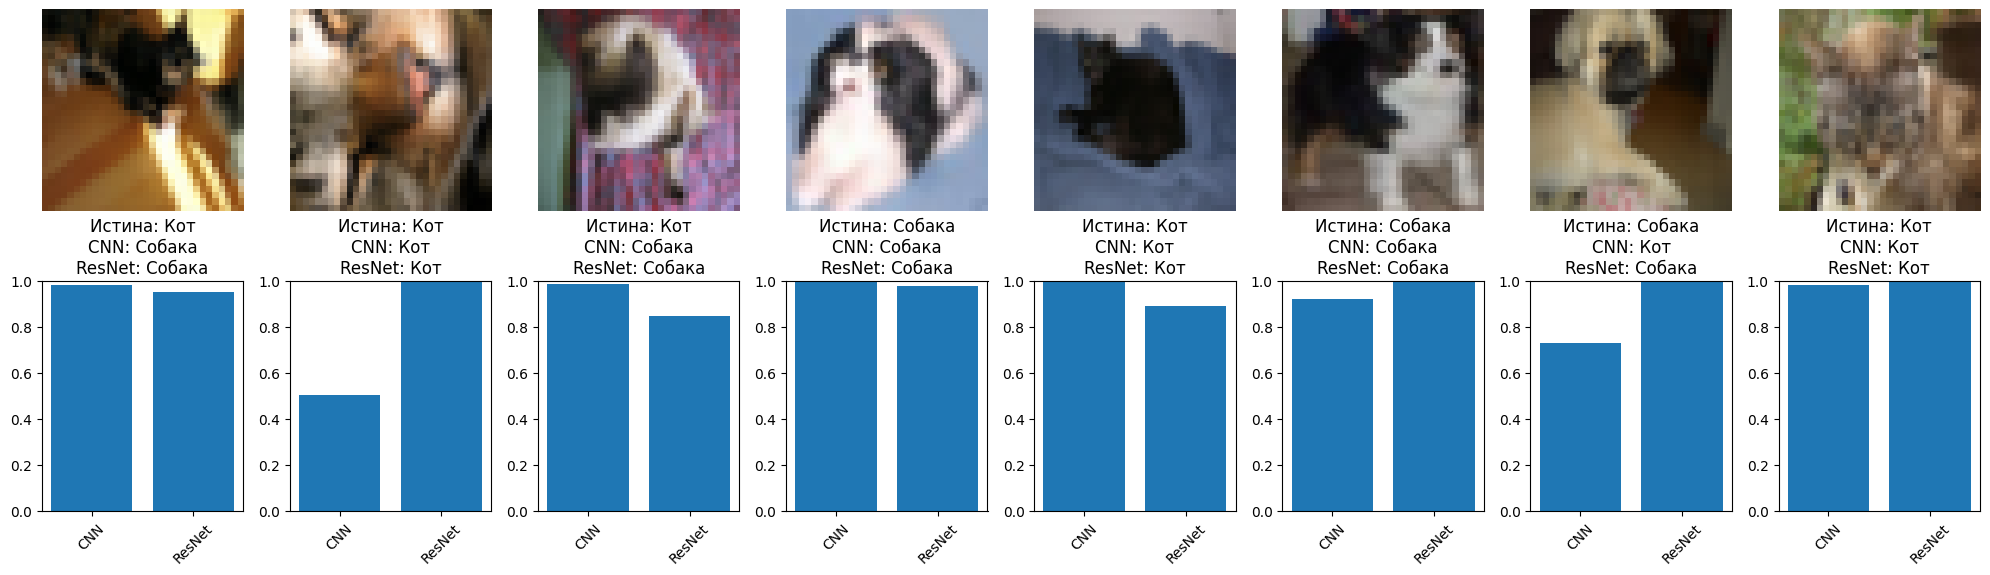

In [ ]:
# Визуализация примеров предсказаний
print("Примеры предсказаний моделей:")

num_examples = 8
random_indices = np.random.choice(len(x_test_binary), num_examples, replace=False)

fig, axes = plt.subplots(2, num_examples, figsize=(20, 6))

for i, idx in enumerate(random_indices):
    axes[0, i].imshow(x_test_binary[idx])
    axes[0, i].axis('off')

    image = x_test_binary[idx:idx+1]
    true_label = y_test_binary[idx]

    cnn_pred = simple_cnn.predict(image, verbose=0)[0][0]
    resnet_pred = resnet_model.predict(image, verbose=0)[0][0]

    cnn_class = "Кот" if cnn_pred > 0.5 else "Собака"
    resnet_class = "Кот" if resnet_pred > 0.5 else "Собака"
    true_class = "Кот" if true_label == 1 else "Собака"

    axes[1, i].bar(['CNN', 'ResNet'], [cnn_pred if cnn_pred > 0.5 else 1-cnn_pred,
                                      resnet_pred if resnet_pred > 0.5 else 1-resnet_pred])
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_title(f'Истина: {true_class}\nCNN: {cnn_class}\nResNet: {resnet_class}')
    axes[1, i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()